# El Contexto Comercial y la Recuperación de Datos

En este notebook se desarrollará el arco narrativo final del proyecto, conectando los análisis realizados en semanas anteriores con indicadores clave de desempeño. El objetivo es transformar los datos trabajados previamente en información útil para la toma de decisiones en distintos niveles organizacionales: estratégico, táctico y operacional.

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

ruta_datos = "/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos"
df_completos = spark.read.parquet(ruta_datos)

ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_historico = spark.read.parquet(ruta_datos)

total_registros = df_historico.count()

print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} productos del histórico.")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos.

In [2]:
import os

os.listdir("/home/jovyan/work/semanas")

['.ipynb_checkpoints',
 'Reset',
 'Semana 1 Configuración del Entorno',
 'Semana 10 Clustering',
 'Semana 12 Pseudo-labeling',
 'Semana 14. Storytelling',
 'Semana 2 Scrapping Estatico',
 'Semana 3 Scraping Dinamico',
 'Semana 4 Mongo DB',
 'Semana 5 MongoDB PySpark',
 'Semana 6 Integracion',
 'Semana 7 La union',
 'Semana 9 EDA Spark']

In [3]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import os

spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

ruta_semana9 = "/home/jovyan/work/semanas/Semana 9 EDA Spark"
ruta_semana10 = "/home/jovyan/work/semanas/Semana 10 Clustering"

print("Archivos Semana 9:")
print(os.listdir(ruta_semana9))

print("\nArchivos Semana 10:")
print(os.listdir(ruta_semana10))

Archivos Semana 9:
['salidas']

Archivos Semana 10:
['modelos', 'salidas']


In [4]:
import os

ruta_semana9_salidas = "/home/jovyan/work/semanas/Semana 9 EDA Spark/salidas"
ruta_semana10_modelos = "/home/jovyan/work/semanas/Semana 10 Clustering/modelos"
ruta_semana10_salidas = "/home/jovyan/work/semanas/Semana 10 Clustering/salidas"

print("Semana 9 / salidas:")
print(os.listdir(ruta_semana9_salidas))

print("\nSemana 10 / modelos:")
print(os.listdir(ruta_semana10_modelos))

print("\nSemana 10 / salidas:")
print(os.listdir(ruta_semana10_salidas))

Semana 9 / salidas:
['correlacion_pearson.csv', 'correlacion_spearman.csv', 'features_eda_semana9.csv', 'figuras']

Semana 10 / modelos:
['datos_etiquetados_kmeans', 'kmeans_energia_v1']

Semana 10 / salidas:
['clusters_dbscan.csv', 'clusters_kmeans.csv', 'evaluacion_kmeans.csv', 'figuras']


In [5]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

ruta_datos = "/home/jovyan/work/semanas/Semana 10 Clustering/modelos/datos_etiquetados_kmeans"

df_historico = spark.read.parquet(ruta_datos)

total_registros = df_historico.count()

print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} registros del histórico.")

ÉXITO: Conexión establecida. Hemos recuperado 80 registros del histórico.


In [6]:
df_historico.printSchema()

root
 |-- periodo: integer (nullable = true)
 |-- region: string (nullable = true)
 |-- categoria_energia: string (nullable = true)
 |-- generacion_mwh: double (nullable = true)
 |-- emisiones_co2_mt: double (nullable = true)
 |-- total_generacion_region: double (nullable = true)
 |-- intensidad_co2: double (nullable = true)
 |-- participacion_generacion: double (nullable = true)
 |-- log_generacion: double (nullable = true)
 |-- log_emisiones: double (nullable = true)
 |-- z_intensidad: double (nullable = true)
 |-- es_outlier_intensidad: boolean (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)
 |-- pca_array: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- PC1: double (nullable = true)
 |-- PC2: double (nullable = true)
 |-- prediction: integer (nullable = true)



In [7]:
df_historico.show(5)

+-------+------+-----------------+--------------+----------------+-----------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+----------+
|periodo|region|categoria_energia|generacion_mwh|emisiones_co2_mt|total_generacion_region|    intensidad_co2|participacion_generacion|    log_generacion|     log_emisiones|        z_intensidad|es_outlier_intensidad|            features|      scaledFeatures|         pcaFeatures|           pca_array|                PC1|                 PC2|prediction|
+-------+------+-----------------+--------------+----------------+-----------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+--------------------+--------------------+--------------------+------------------

In [8]:
# KPI Estratégico: Participación de generación por categoría energética

total_generacion = df_historico.agg(F.sum("generacion_mwh")).collect()[0][0]

kpi_estrategico = df_historico.groupBy("categoria_energia") \
    .agg(
        F.round(F.sum("generacion_mwh"), 2).alias("Generacion_Total_MWh"),
        F.round((F.sum("generacion_mwh") / total_generacion) * 100, 2).alias("Participacion_Generacion_Porcentaje"),
        F.round(F.sum("emisiones_co2_mt"), 2).alias("Emisiones_Totales_CO2")
    ).orderBy(F.desc("Generacion_Total_MWh"))

print("[KPI ESTRATÉGICO] Participación de generación por categoría energética")
kpi_estrategico.show()

[KPI ESTRATÉGICO] Participación de generación por categoría energética
+-----------------+--------------------+-----------------------------------+---------------------+
|categoria_energia|Generacion_Total_MWh|Participacion_Generacion_Porcentaje|Emisiones_Totales_CO2|
+-----------------+--------------------+-----------------------------------+---------------------+
|            Fosil|       4.973039899E9|                              94.59|        2.926526123E9|
|        Renovable|         2.6688863E8|                               5.08|             770276.0|
|             Otra|         1.7320568E7|                               0.33|          2.4799826E7|
+-----------------+--------------------+-----------------------------------+---------------------+



In [9]:
# KPI Táctico: Intensidad promedio de CO2 por región

kpi_tactico = df_historico.groupBy("region") \
    .agg(
        F.round(F.sum("generacion_mwh"), 2).alias("Generacion_Total_MWh"),
        F.round(F.sum("emisiones_co2_mt"), 2).alias("Emisiones_Totales_CO2"),
        F.round(F.avg("intensidad_co2"), 4).alias("Intensidad_CO2_Promedio")
    ).orderBy(F.desc("Intensidad_CO2_Promedio"))

print("[KPI TÁCTICO] Intensidad de emisiones por región")
kpi_tactico.show(20)

[KPI TÁCTICO] Intensidad de emisiones por región
+------+--------------------+---------------------+-----------------------+
|region|Generacion_Total_MWh|Emisiones_Totales_CO2|Intensidad_CO2_Promedio|
+------+--------------------+---------------------+-----------------------+
|    OK|         1.0785613E8|          5.7537196E7|                 3.9708|
|    VT|              5220.0|              16622.0|                 3.1843|
|    SC|          7.960334E7|          5.3792282E7|                 1.9533|
|    OH|         2.3443907E8|         1.30404212E8|                 1.8385|
|    WI|         9.4174891E7|          6.4628766E7|                 1.2764|
|    OR|         4.9904767E7|          2.0646498E7|                 1.2418|
|    AR|         8.0895279E7|          5.3689545E7|                 1.2381|
|    NY|        1.27331087E8|          6.3025756E7|                 1.2243|
|    MD|          3.385234E7|          1.9435454E7|                 1.2122|
|    VA|         1.2719983E8|          

In [10]:
# KPI Operacional: Alertas críticas por outliers de intensidad de CO2

kpi_operacional_alertas = df_historico.filter(
    F.col("es_outlier_intensidad") == True
).select(
    "periodo",
    "region",
    "categoria_energia",
    "generacion_mwh",
    "emisiones_co2_mt",
    "intensidad_co2",
    "z_intensidad",
    "prediction"
).orderBy(F.desc("intensidad_co2"))

print("[KPI OPERACIONAL] Alertas críticas de intensidad de CO2")
print(f"Total de alertas detectadas: {kpi_operacional_alertas.count()}")

kpi_operacional_alertas.show(20)

[KPI OPERACIONAL] Alertas críticas de intensidad de CO2
Total de alertas detectadas: 6
+-------+------+-----------------+--------------+----------------+------------------+------------------+----------+
|periodo|region|categoria_energia|generacion_mwh|emisiones_co2_mt|    intensidad_co2|      z_intensidad|prediction|
+-------+------+-----------------+--------------+----------------+------------------+------------------+----------+
|   2024|    OK|             Otra|       46366.0|        343620.0| 7.411033947288962| 6.444829955002216|         2|
|   2024|    SC|             Otra|       91326.0|        295330.0|3.2337997941440553|2.2432804290339874|         2|
|   2024|    VT|            Fosil|        5220.0|         16622.0|3.1842911877394635| 2.193483636672239|         2|
|   2024|    OH|             Otra|        7716.0|         24080.0|3.1207879730430275|2.1296107744329036|         2|
|   2024|    OR|             Otra|       26975.0|         55860.0|2.0708063021316034|1.07351723742782

# Storytelling de los KPIs

A nivel estratégico, el análisis permite identificar qué categorías energéticas concentran la mayor parte de la generación. Esto es relevante porque una alta participación de energía fósil puede representar dependencia de fuentes contaminantes y un desafío para la transición energética.

A nivel táctico, la comparación entre regiones permite observar cuáles presentan mayor intensidad de emisiones de CO₂. Este indicador ayuda a priorizar regiones donde se podrían implementar estrategias de eficiencia energética o sustitución por fuentes más limpias.

A nivel operacional, las alertas de intensidad crítica permiten detectar casos atípicos que requieren revisión inmediata. Estos registros pueden representar problemas de eficiencia, alta dependencia fósil o comportamientos anómalos dentro del sistema energético.

En conjunto, los KPIs permiten transformar el análisis técnico en una herramienta de apoyo para la toma de decisiones en energía y sustentabilidad.

# Gráfico 1: KPI Estratégico

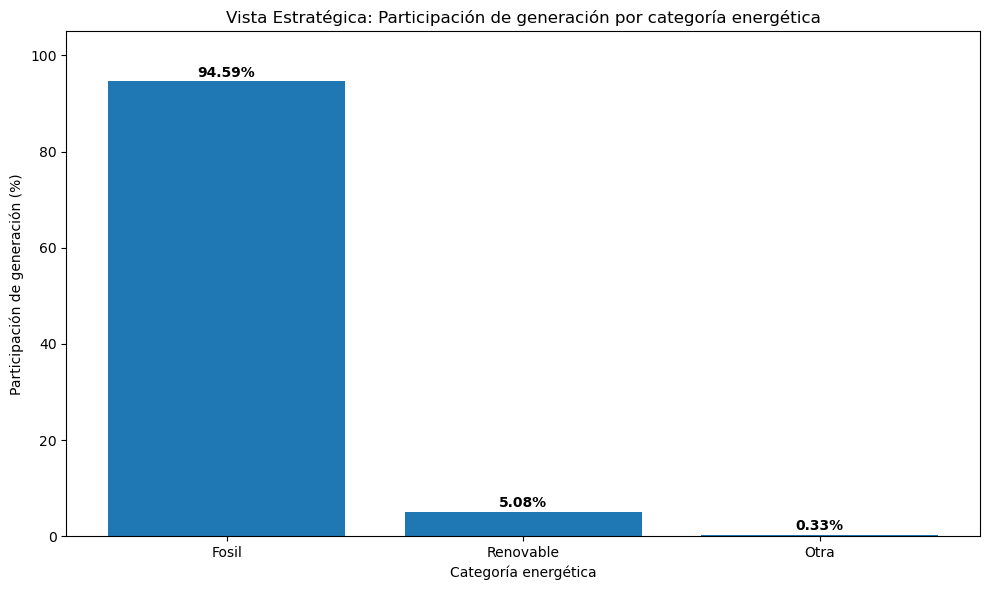

In [11]:
import matplotlib.pyplot as plt

df_est_pandas = kpi_estrategico.toPandas()

plt.figure(figsize=(10, 6))
plt.bar(df_est_pandas["categoria_energia"], df_est_pandas["Participacion_Generacion_Porcentaje"])

for i, valor in enumerate(df_est_pandas["Participacion_Generacion_Porcentaje"]):
    plt.text(i, valor + 1, f"{valor:.2f}%", ha="center", fontweight="bold")

plt.title("Vista Estratégica: Participación de generación por categoría energética")
plt.xlabel("Categoría energética")
plt.ylabel("Participación de generación (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# Gráfico 2: KPI Táctico

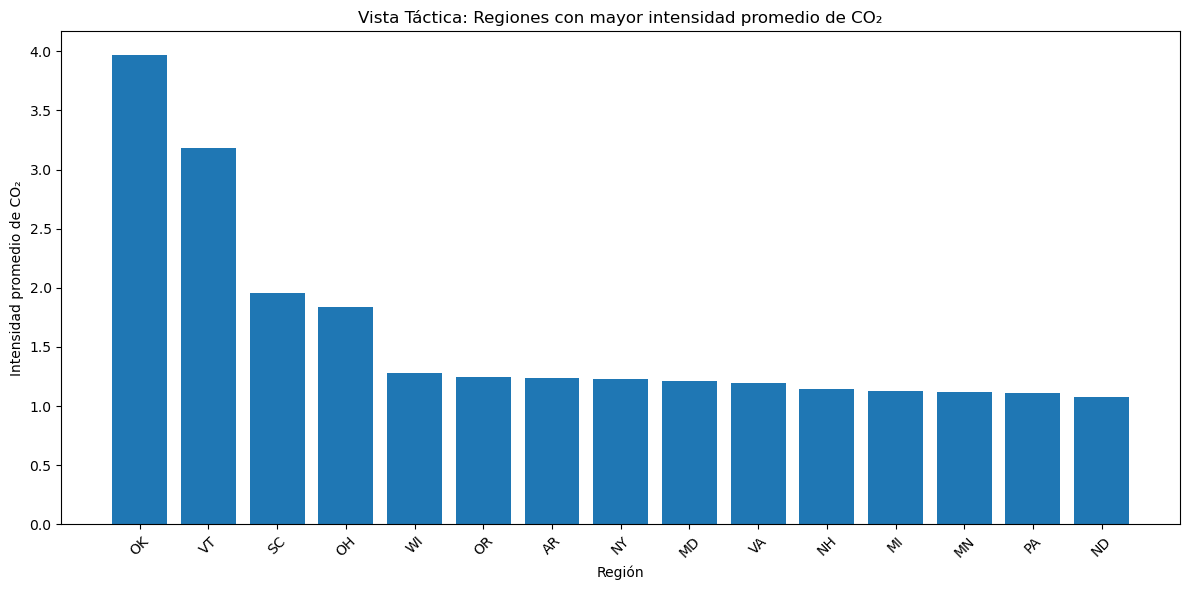

In [12]:
df_tac_pandas = kpi_tactico.limit(15).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(df_tac_pandas["region"], df_tac_pandas["Intensidad_CO2_Promedio"])

plt.title("Vista Táctica: Regiones con mayor intensidad promedio de CO₂")
plt.xlabel("Región")
plt.ylabel("Intensidad promedio de CO₂")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 3: KPI Operacional

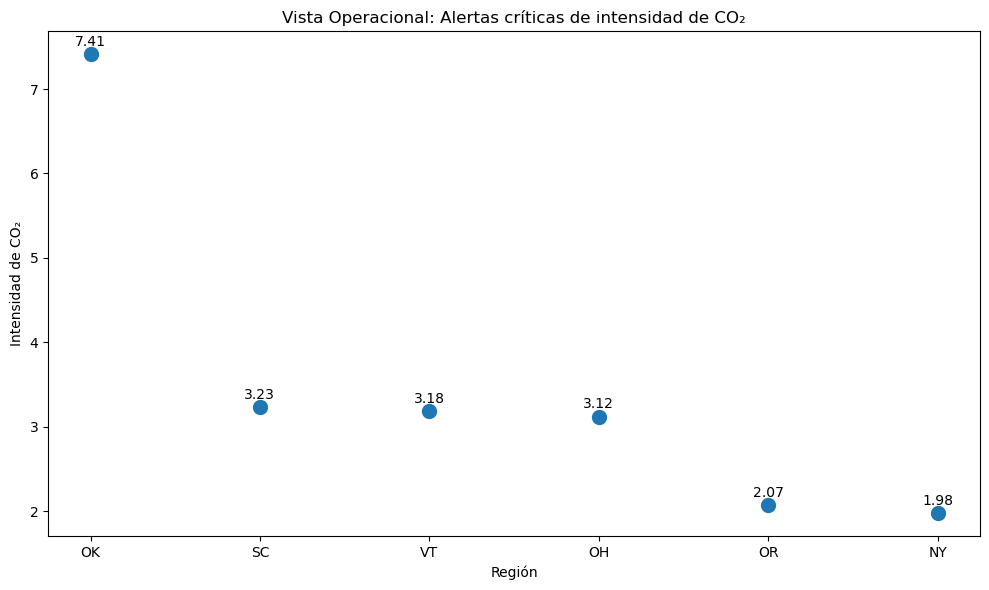

In [13]:
df_op_pandas = kpi_operacional_alertas.toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(df_op_pandas["region"], df_op_pandas["intensidad_co2"], s=100)

for i, row in df_op_pandas.iterrows():
    plt.text(row["region"], row["intensidad_co2"] + 0.1, f'{row["intensidad_co2"]:.2f}', ha="center")

plt.title("Vista Operacional: Alertas críticas de intensidad de CO₂")
plt.xlabel("Región")
plt.ylabel("Intensidad de CO₂")
plt.tight_layout()
plt.show()

# Storytelling de los KPIs

A nivel estratégico, el análisis muestra que la generación energética se concentra principalmente en fuentes fósiles, con una participación cercana al 95% del total. Esto evidencia una alta dependencia de este tipo de energía, lo que representa un desafío para la sustentabilidad y para una posible transición hacia fuentes más limpias.

A nivel táctico, la comparación por regiones permite identificar aquellas zonas con mayor intensidad promedio de CO₂. Regiones como OK, VT, SC y OH presentan valores elevados, lo que indica que su generación energética tiene un mayor impacto ambiental en relación con la energía producida. Esta información puede apoyar decisiones sobre eficiencia energética, planificación regional y priorización de medidas de reducción de emisiones.

A nivel operacional, se detectaron seis alertas críticas asociadas a comportamientos atípicos en la intensidad de CO₂. La región OK destaca como el caso más crítico, con una intensidad muy superior al resto. Estas alertas permiten actuar de manera más rápida, revisando posibles causas como dependencia de fuentes fósiles, baja eficiencia o registros anómalos.

En conjunto, los KPIs permiten transformar el análisis técnico del EDA y del clustering en una historia útil para la toma de decisiones. El mensaje principal es que el sistema energético analizado presenta una fuerte dependencia fósil, diferencias regionales relevantes y casos críticos que requieren monitoreo.

# Conclusiones

El desarrollo de la Semana 14 permitió transformar los resultados técnicos del análisis exploratorio y del clustering en una narrativa orientada a la toma de decisiones. A través de los KPIs estratégico, táctico y operacional, fue posible interpretar los datos de energía y sustentabilidad desde distintos niveles organizacionales.

A nivel estratégico, se identificó una fuerte dependencia de la generación fósil, la cual representa cerca del 95% de la generación total. Esto evidencia un desafío relevante para avanzar hacia una matriz energética más diversificada y sustentable.

A nivel táctico, se observaron diferencias importantes entre regiones respecto a la intensidad promedio de CO₂. Regiones como OK, VT, SC y OH presentan valores elevados, por lo que podrían ser priorizadas en estrategias de eficiencia energética y reducción de emisiones.

A nivel operacional, se detectaron seis alertas críticas asociadas a comportamientos atípicos en la intensidad de CO₂. Estos casos permiten establecer un monitoreo más directo para identificar riesgos ambientales o posibles anomalías en los datos.

En conclusión, el análisis demuestra que los datos no solo permiten describir una situación, sino también construir una historia útil para apoyar decisiones estratégicas, tácticas y operacionales en el ámbito de energía y sustentabilidad.